### Red wine data, dataset evaluation report

**This example is a bit more simple than the two others. However, it would be possible to add more analysis here if needed.**

## General information

Target variable is **quality**, which implies the quality of the red wine (range, 3 - 8, 3 implies worst and 8 implies best quality).

**Other variables in the dataset:**

- fixed acidity
- volatile acidity 
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol

There seems to some duplicate samples in the dataset (13.8%). This might be a problem, since we have less than 1600 samples in the dataset, which are distributed among 6 different target categories.

There are no missing values in the dataset.

## Variables to drop or to process further

We probably don't want to drop any of the variables for now, they all seem useful from the target variable point of view. Not all of the variables initially correlate highly towards the quality, but we want to keep these variables just in case there are some hidden connections between the variables.

Depending on the target variable (quality), we might create new variables based on existing variables (clustering, target encoding, feature synthesis) etc.

All the variables seem quite usable, since all the support variable are technically just continuous measurement values.

## Variable importance and redundancy analysis

phik-matrix results:

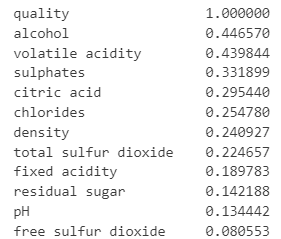

Everything else except maybe free sulfur dioxide (and it still is 8%) seems to have effect towards the quality of the red wine. 

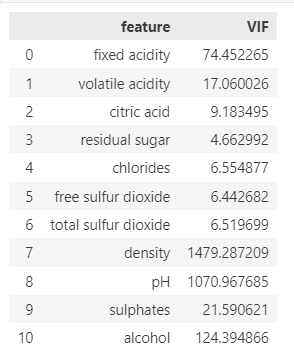

density and pH imply a slight multicollinearity, might be a potential variable to remove if the need arises. Surprisingly, the acidities don't have such a high multicollinearity.

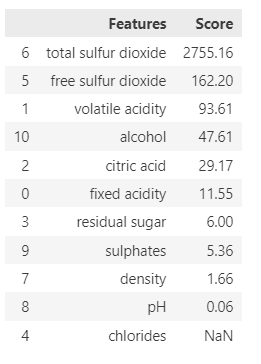

In SelectKBest, both sulfurs are important, chlorides are not important here, however they were important in the phik-matrix.

## Distributions and imbalances

The target variable has a rough normal distribution with a fairly high kurtosis.

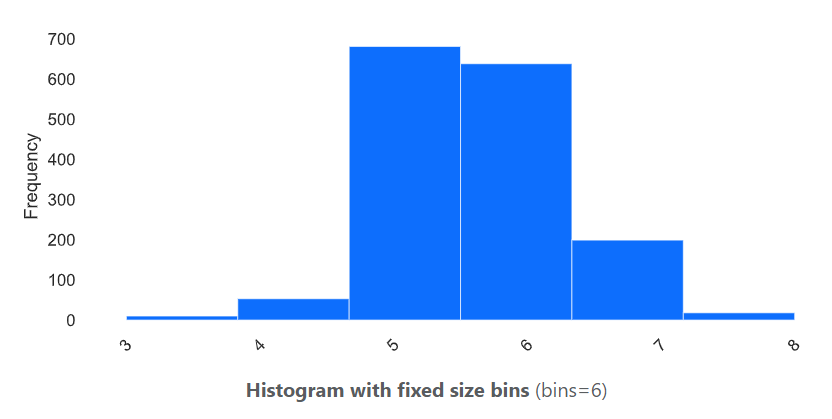

We can see how the average qualities 5 and 6 are over-represented, while quality categories 3, 4 and 8 are extremely underrepresented. Since we are going to attempt classification with this dataset later, this will be a serious issue, which has to be mitigated. Data synthetization might be a good option (SMOTE etc.). Undersampling is probably not an option (at least not without synthetization), since we don't have enough data in the low and high categories.

Many of the support variables have a rough normal distribution (or slightly skewed towards lower end), which is probably ok, since they match well with the target variable distribution as well. 

This means, when we attempt fixing the target variable distribution (quality), we most likely will also adjust the support variable distributions at the same time. 

For example, volatile acidity:

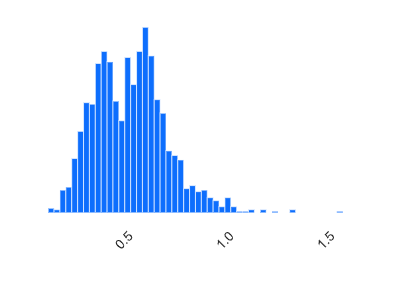

Or alcohol percentage (more skewed though and with some peaks involved):

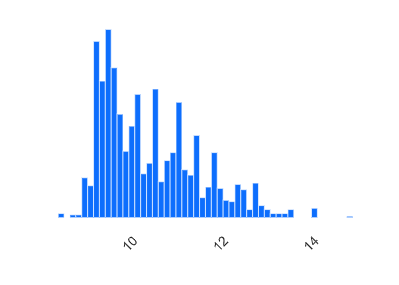

citric acidity does not follow a normal distribution though:

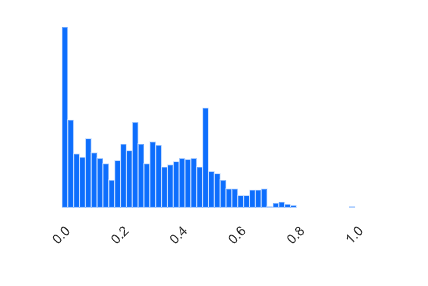

The citric acidity values are more stacked around the 0.0 -value. We have to keep this in mind if this variable proves to bring noise or overlap to the dataset.

## Irregularities in trends / contradictions

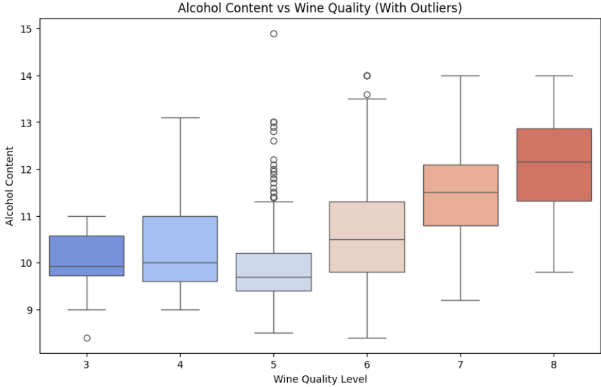

In this case, we have some noise, outliers or overlap in the wine quality, especially in quality level 5, which breaks the overall trend.

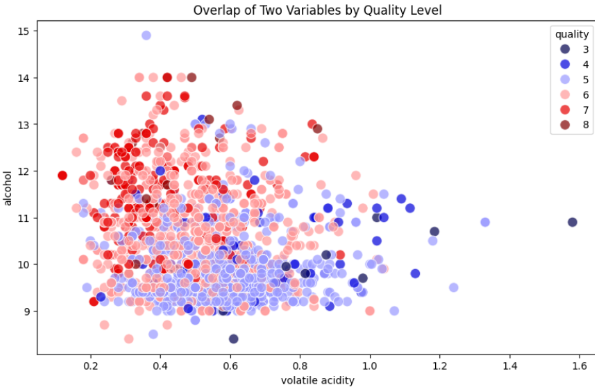

There's some distinquishion between the alcohol level and volatile acidity, but it's not very clear. This can be considered overlap and noise, also some outliers in the sides.

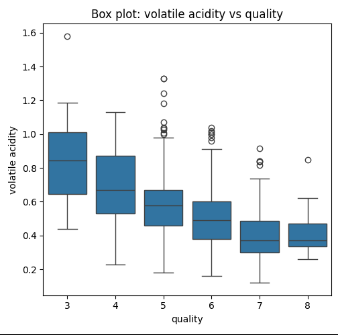

Volatile acidity has a cleaner trend than alcohol level, even though some outliers and noise is present on the sides.

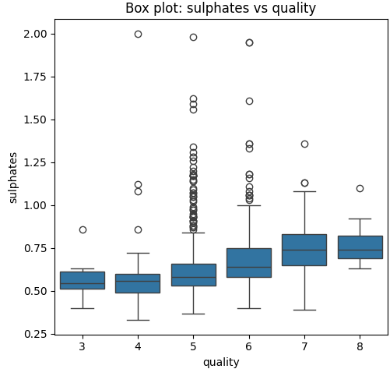

Fairly simple trend, although a heavy amount of outliers in quality levels 5-6.

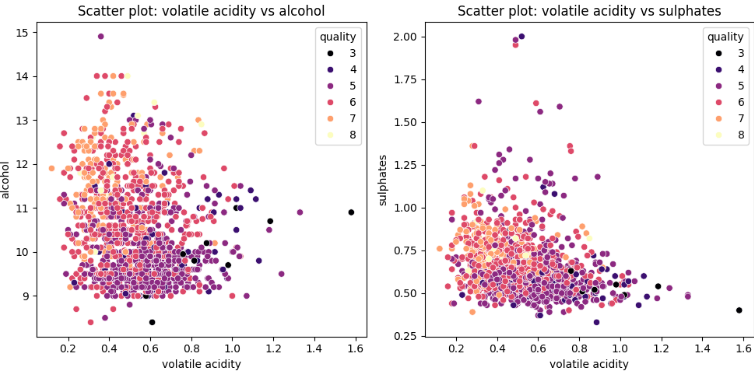

These scatter plots show the main problem of this dataset, there's a fuzzy logic and distinquishion between the quality levels, but the quality levels are leaking between acidity and alcohol levels. There's a huge section in the middle, where it's uncertain what the quality level is regarding alcohol level and acidity.

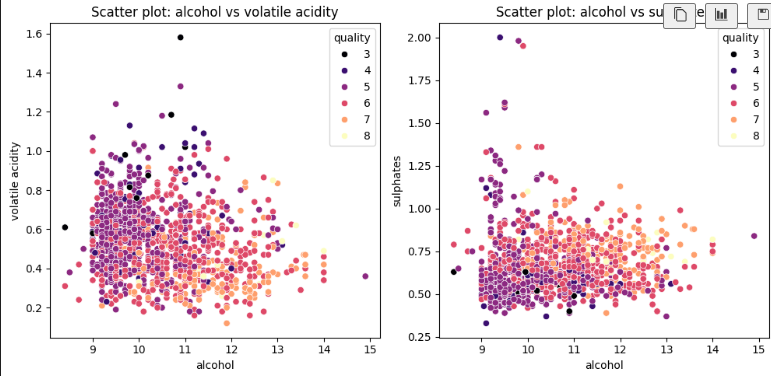

More of the same as previously. The dataset looks potential, but we need to optimize the overlapping, noise and outliers in order to get this dataset to work better with machine learning models. Clustering algorithms might also be efficient here.

## Noise / outliers

Noise detected by isolation forest, 0.05 contamination.

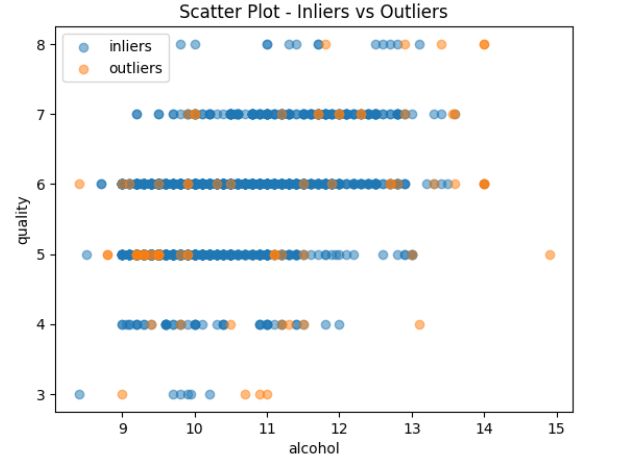

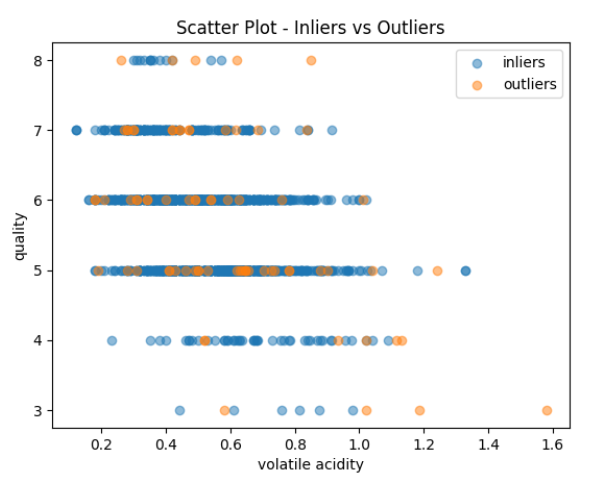

It seems most outliers and noise are within the dataset, which might be due to overlap issues between quality classes.

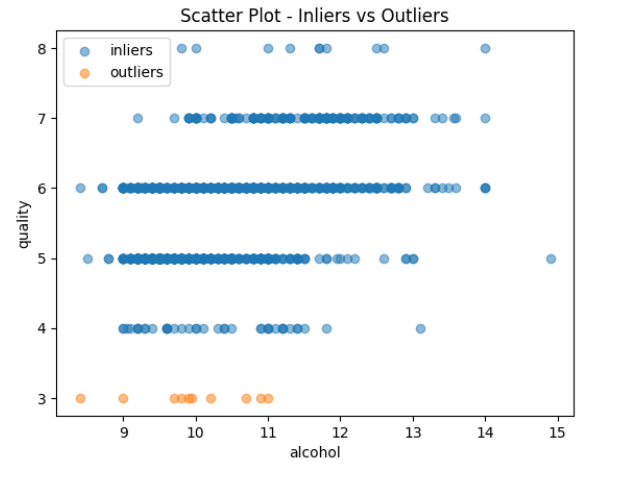

Only lowest quality levels were marked as noise. This is probably due to the high imbalance in target quality (thus being outlier or noise decided by MAD)

## SHAP / LIME

Let's study the SHAP summary:

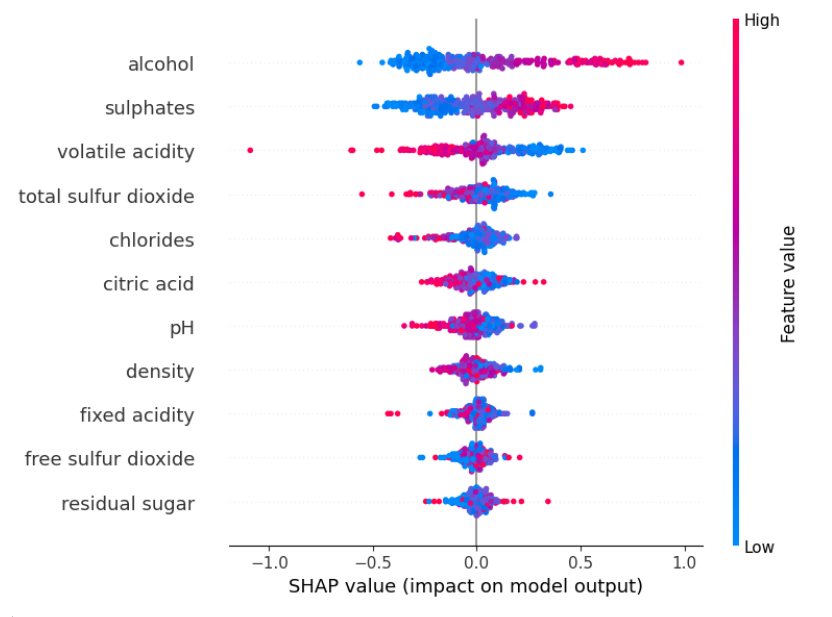

Most variables are quite impactful here, however, fixed acidity, free sulfur dioxide and residual sugar seem to be the least important, maybe even implying noise in the dataset.

LIME result (used regression mode since the quality target is an ordinal category)

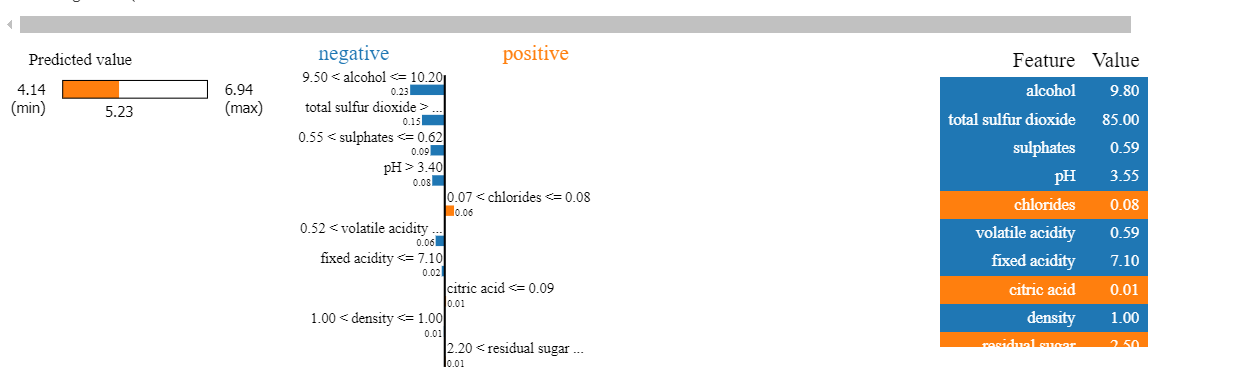

residual sugar not affecting much here.

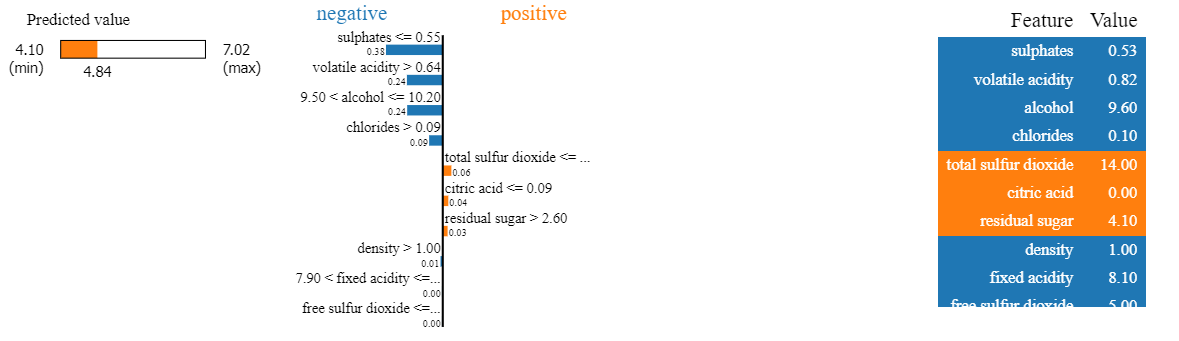

But here the sugar is affecting. It seems the middle level wines are quite noisy in the predictions.

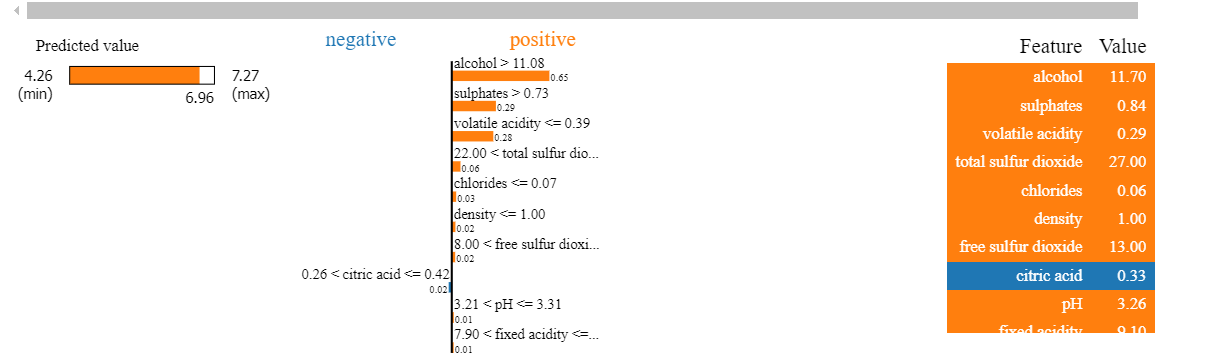

In high level wine, alcohol, sulphates and volatile acidity really affect the prediction. 

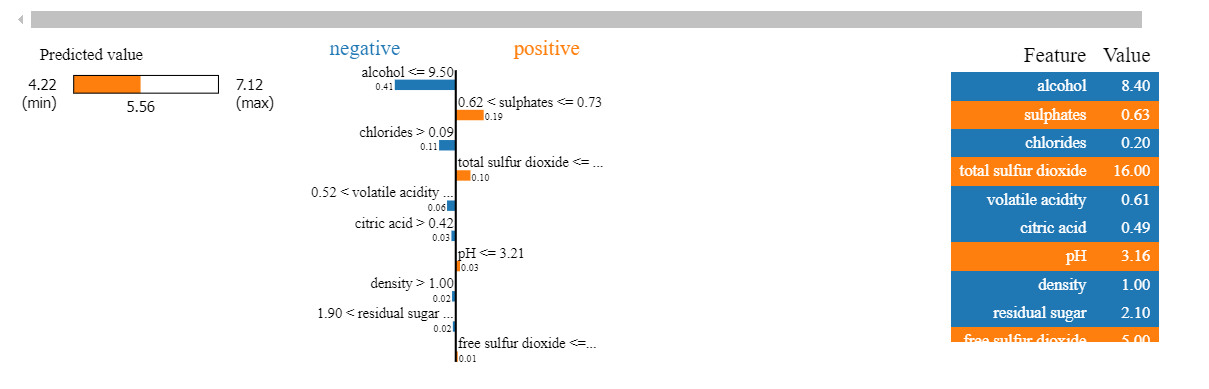

This is a low quality wine (3), but predicted much higher. The results here are different than the middle range wine.

## Summary of key points:

- There's a very clear and serious overlap between the red wine quality, alcohol content and volatile acidity
    - The rough trend is, as quality goes up => alcohol goes and volatile acidity goes down... EXCEPT when we are in the average quality levels, when it can be either/or
    - Clustering, TomekLinks, PCA etc. or other optimization methods can be experimented with in order to differntiate between the average quality levels a bit more

- The dataset has mostly measurements in the variables, no categorical variables except the target variable itself
    - this means we'll mostly focus on outlier, noise, distribution management and other similar tools, common in regression datasets as well

- Most variables have a notable connection to target variable (quality), this might imply we might want to keep all original variables, at least in the beginning of optimization
    - however, some tools, like SHAP, imply we might have noisy variable that can be removed, like fixed acidity, free sulfur dioxide and residual sugar

___

In [ ]:
# to be continued on a lecture/workshop

# TODO:

# target and support variable distributions
# analyze imbalances in variables (especially the target variable)

# compare trends, any contradictions towards the target variable? (there should be plenty in this dataset)
# noise/overlap (heavily related to the overall trends, this dataset is quite problematic with overlap)
# redundancy in variables (VIF-test + visualizations + others)
# outliers in the data (not much data in this dataset either)
# missing data, duplicates?
# ideas for combining and/or removing variables in this dataset?
# ideas on how to handle the small amount of data and high imbalance?

# SHAP / LIME

